<a href="https://colab.research.google.com/github/Sebastian-Tamez/PDI_Laboratorio/blob/main/P8_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imagen cargada correctamente


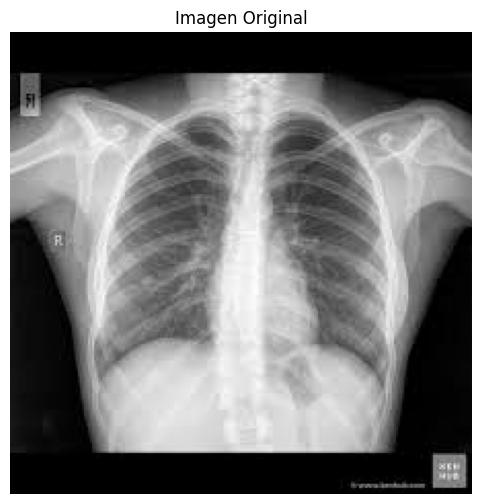

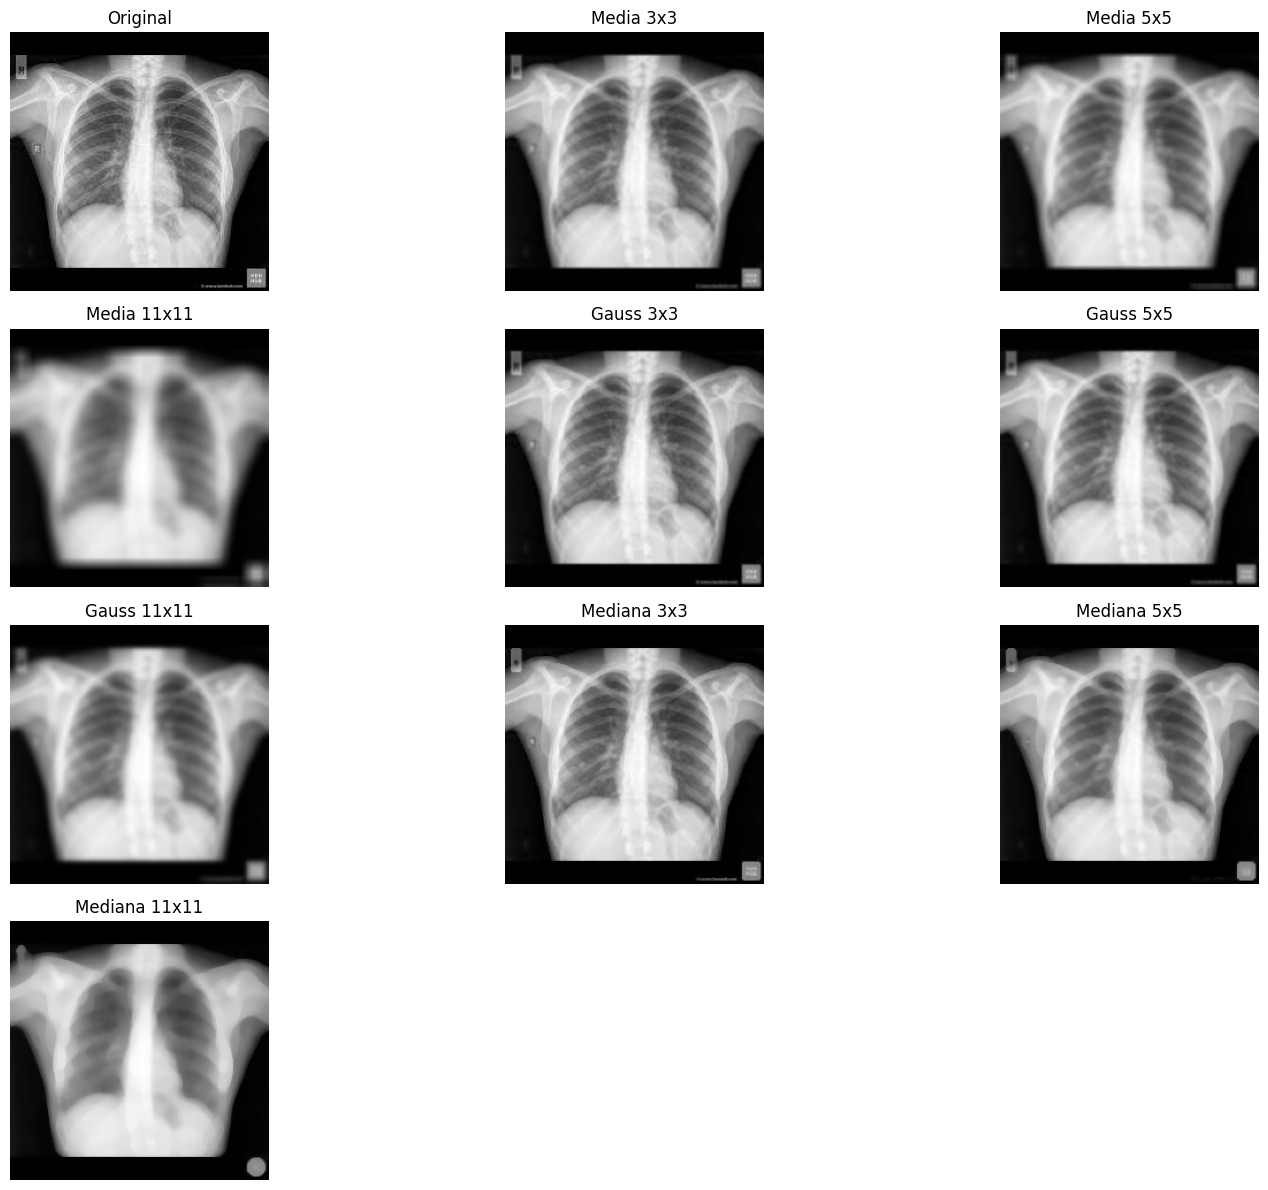

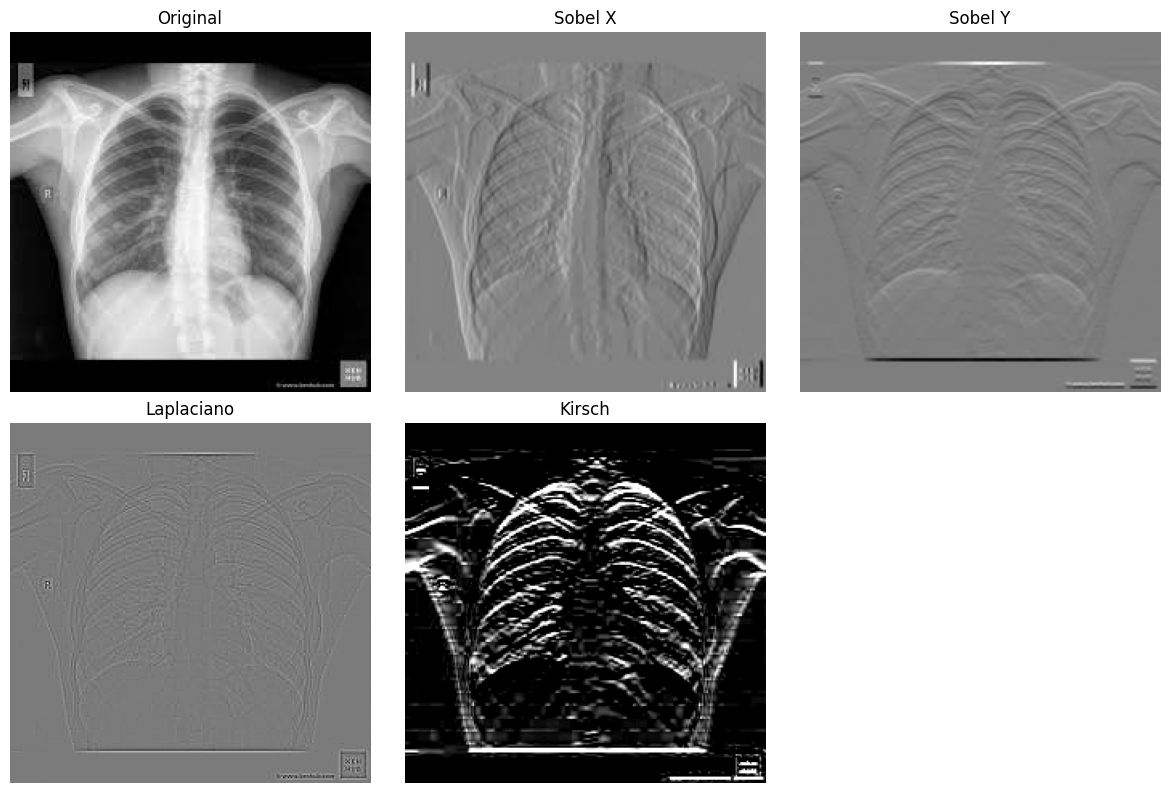

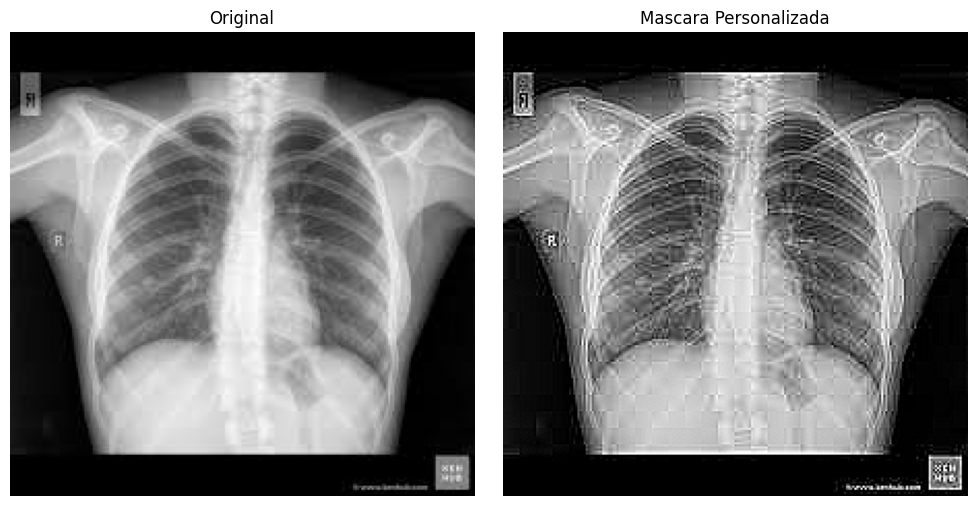

Practica finalizada correctamente


In [ ]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen = cv2.imread('radiografia.jpg', cv2.IMREAD_GRAYSCALE)

if imagen is None:
    print("Error: No se encontró la imagen")
else:
    print("Imagen cargada correctamente")

plt.figure(figsize=(6,6))
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.show()


# FILTRO MEDIA
media_3 = cv2.blur(imagen, (3,3))
media_5 = cv2.blur(imagen, (5,5))
media_11 = cv2.blur(imagen, (11,11))

# FILTRO GAUSSIANO
gauss_3 = cv2.GaussianBlur(imagen, (3,3), 0)
gauss_5 = cv2.GaussianBlur(imagen, (5,5), 0)
gauss_11 = cv2.GaussianBlur(imagen, (11,11), 0)

# FILTRO MEDIANA
mediana_3 = cv2.medianBlur(imagen, 3)
mediana_5 = cv2.medianBlur(imagen, 5)
mediana_11 = cv2.medianBlur(imagen, 11)


imagenes_suavizado = [
    imagen,
    media_3, media_5, media_11,
    gauss_3, gauss_5, gauss_11,
    mediana_3, mediana_5, mediana_11
]

nombres_suavizado = [
    'Original',
    'Media 3x3', 'Media 5x5', 'Media 11x11',
    'Gauss 3x3', 'Gauss 5x5', 'Gauss 11x11',
    'Mediana 3x3', 'Mediana 5x5', 'Mediana 11x11'
]

plt.figure(figsize=(15,12))

for i in range(len(imagenes_suavizado)):
    plt.subplot(4,3,i+1)
    plt.imshow(imagenes_suavizado[i], cmap='gray')
    plt.title(nombres_suavizado[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# SOBEL X
sobelx = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)

# SOBEL Y
sobely = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)

# LAPLACIANO
laplaciano = cv2.Laplacian(imagen, cv2.CV_64F)

# KIRSCH
kernel_kirsch = np.array([
    [5, 5, 5],
    [-3, 0, -3],
    [-3, -3, -3]
])

kirsch = cv2.filter2D(imagen, -1, kernel_kirsch)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(imagen, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(sobelx, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobely, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(laplaciano, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(kirsch, cmap='gray')
plt.title('Kirsch')
plt.axis('off')

plt.tight_layout()
plt.show()


kernel_personalizado = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

realce = cv2.filter2D(imagen, -1, kernel_personalizado)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagen, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(realce, cmap='gray')
plt.title('Mascara Personalizada')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Practica finalizada correctamente")

# Parte II
Filtros en el Dominio de la Frecuencia con Parámetros Modificables


Por favor, selecciona y sube tu imagen (ej. Endoscopia.jpg):


Saving Endoscopia.jpg to Endoscopia.jpg

¡Imagen 'Endoscopia.jpg' cargada con éxito!


/tmp/ipykernel_6335/2405526191.py:88: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


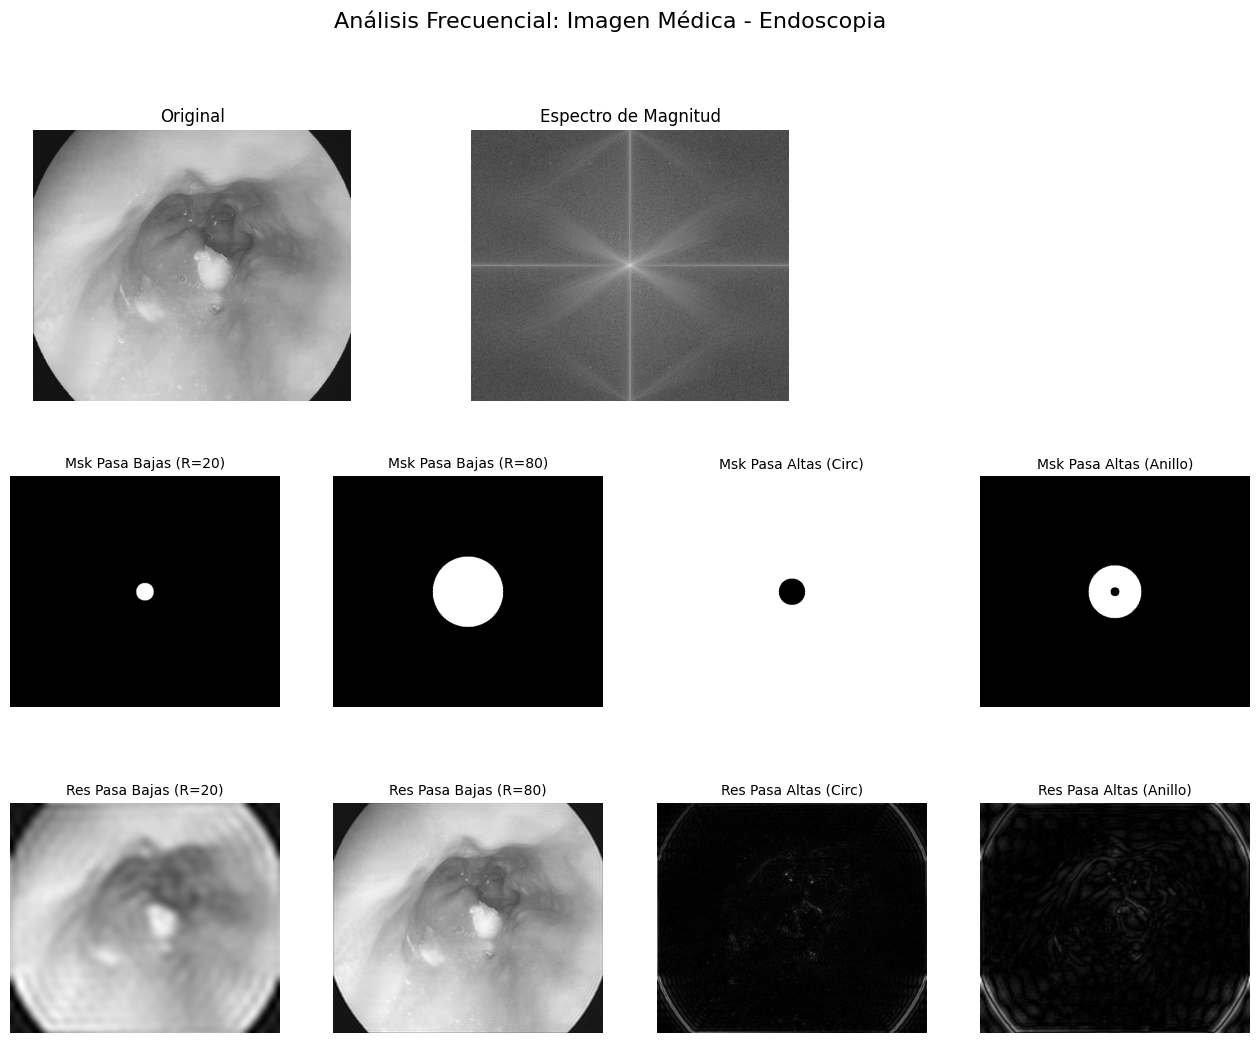

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files # Librería para subir archivos en Colab
import os

def procesar_frecuencia(path_imagen, titulo_medico):
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(path_imagen, 0)
    if img is None:
        print(f"No se encontró la imagen en: {path_imagen}")
        return

    # 2. Transformada de Fourier y desplazamiento al centro
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # --- DEFINICIÓN DE MÁSCARAS ---

    # Filtros Pasa Bajas (Radios 20 y 80)
    mask_pb_20 = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pb_20, (ccol, crow), 20, 1, -1)

    mask_pb_80 = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pb_80, (ccol, crow), 80, 1, -1)

    # Filtros Pasa Altas (Circular y Anillo)
    mask_pa_circ = np.ones((rows, cols), np.uint8)
    cv2.circle(mask_pa_circ, (ccol, crow), 30, 0, -1)

    # Anillo: Bloquea bajas y muy altas, solo deja pasar una banda
    mask_pa_anillo = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pa_anillo, (ccol, crow), 60, 1, -1) # Círculo exterior
    cv2.circle(mask_pa_anillo, (ccol, crow), 10, 0, -1) # Hueco interior

    filtros = [
        ("Pasa Bajas (R=20)", mask_pb_20),
        ("Pasa Bajas (R=80)", mask_pb_80),
        ("Pasa Altas (Circ)", mask_pa_circ),
        ("Pasa Altas (Anillo)", mask_pa_anillo)
    ]

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(16, 12)) # Un poco más alto para acomodar bien el grid
    plt.suptitle(f"Análisis Frecuencial: {titulo_medico}", fontsize=16)

    # Mostrar Original
    plt.subplot(3, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Mostrar Espectro de Magnitud
    mag_spectrum = 20 * np.log(np.abs(fshift) + 1)
    plt.subplot(3, 3, 2)
    plt.imshow(mag_spectrum, cmap='gray')
    plt.title("Espectro de Magnitud")
    plt.axis('off')

    # Posiciones fijas en el grid 3x3 para evitar conflictos en el bucle
    pos_mascaras = [3, 4, 5, 6]   # Fila del medio y parte de la última
    pos_resultados = [7, 8, 9, 9] # Corrección de los índices para el subplot

    # Aplicar y mostrar cada filtro
    for i, (nombre, mask) in enumerate(filtros):
        # Aplicar máscara
        fshift_filtered = fshift * mask

        # Inversa
        f_ishift = np.fft.ifftshift(fshift_filtered)
        img_back = np.abs(np.fft.ifft2(f_ishift))

        # Dibujar Máscara (Fila 2 del subplot)
        plt.subplot(3, 4, i + 5)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Msk {nombre}", fontsize=10)
        plt.axis('off')

        # Dibujar Resultado (Fila 3 del subplot)
        plt.subplot(3, 4, i + 9)
        plt.imshow(img_back, cmap='gray')
        plt.title(f"Res {nombre}", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Por favor, selecciona y sube tu imagen (ej. Endoscopia.jpg):")
uploaded = files.upload()

# Obtener el nombre del archivo que acabas de subir
if uploaded:
    nombre_archivo = list(uploaded.keys())[0]
    print(f"\n¡Imagen '{nombre_archivo}' cargada con éxito!")

    # Ejecutar la función con el archivo subido
    procesar_frecuencia(nombre_archivo, 'Imagen Médica - Endoscopia')
else:
    print("No se subió ningún archivo.")

EJEMPLO CON SEGUNDA IMÁGEN

Por favor, selecciona y sube tu imagen (ej. Colonoscoía.png):


Saving Colonoscopia.png to Colonoscopia.png

¡Imagen 'Colonoscopia.png' cargada con éxito!


/tmp/ipykernel_6335/600966617.py:88: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


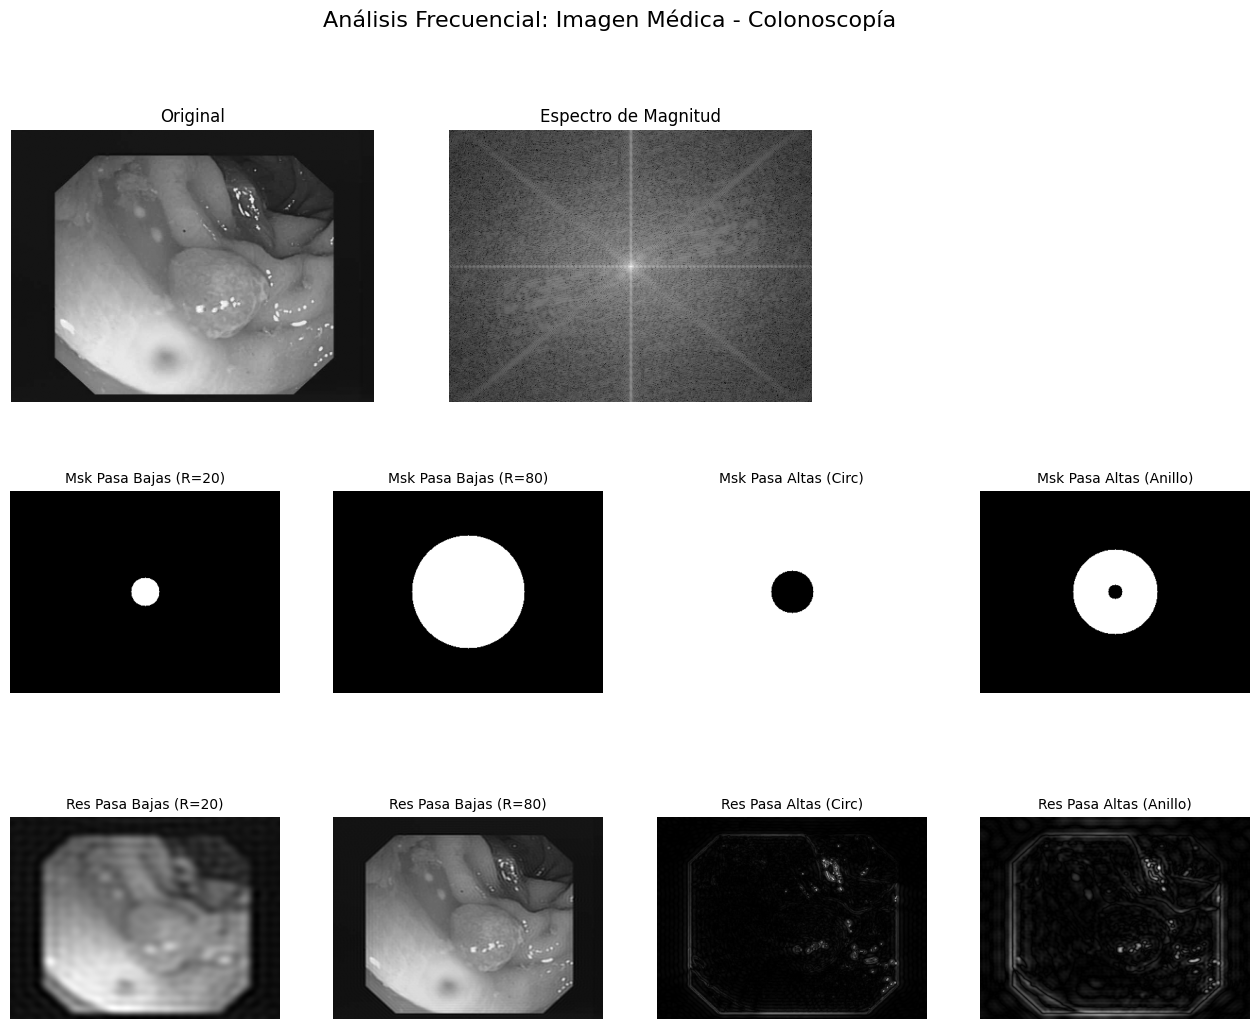

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files # Librería para subir archivos en Colab
import os

def procesar_frecuencia(path_imagen, titulo_medico):
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(path_imagen, 0)
    if img is None:
        print(f"No se encontró la imagen en: {path_imagen}")
        return

    # 2. Transformada de Fourier y desplazamiento al centro
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Filtros Pasa Bajas (Radios 20 y 80)
    mask_pb_20 = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pb_20, (ccol, crow), 20, 1, -1)

    mask_pb_80 = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pb_80, (ccol, crow), 80, 1, -1)

    # Filtros Pasa Altas (Circular y Anillo)
    mask_pa_circ = np.ones((rows, cols), np.uint8)
    cv2.circle(mask_pa_circ, (ccol, crow), 30, 0, -1)

    # Anillo: Bloquea bajas y muy altas, solo deja pasar una banda
    mask_pa_anillo = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_pa_anillo, (ccol, crow), 60, 1, -1) # Círculo exterior
    cv2.circle(mask_pa_anillo, (ccol, crow), 10, 0, -1) # Hueco interior

    filtros = [
        ("Pasa Bajas (R=20)", mask_pb_20),
        ("Pasa Bajas (R=80)", mask_pb_80),
        ("Pasa Altas (Circ)", mask_pa_circ),
        ("Pasa Altas (Anillo)", mask_pa_anillo)
    ]

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"Análisis Frecuencial: {titulo_medico}", fontsize=16)

    # Mostrar Original
    plt.subplot(3, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Mostrar Espectro de Magnitud
    mag_spectrum = 20 * np.log(np.abs(fshift) + 1)
    plt.subplot(3, 3, 2)
    plt.imshow(mag_spectrum, cmap='gray')
    plt.title("Espectro de Magnitud")
    plt.axis('off')

    # Posiciones fijas en el grid 3x3 para evitar conflictos en el bucle
    pos_mascaras = [3, 4, 5, 6]   # Fila del medio y parte de la última
    pos_resultados = [7, 8, 9, 9] # Corrección de los índices para el subplot

    # Aplicar y mostrar cada filtro
    for i, (nombre, mask) in enumerate(filtros):
        # Aplicar máscara
        fshift_filtered = fshift * mask

        # Inversa
        f_ishift = np.fft.ifftshift(fshift_filtered)
        img_back = np.abs(np.fft.ifft2(f_ishift))

        # Dibujar Máscara (Fila 2 del subplot)
        plt.subplot(3, 4, i + 5)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Msk {nombre}", fontsize=10)
        plt.axis('off')

        # Dibujar Resultado (Fila 3 del subplot)
        plt.subplot(3, 4, i + 9)
        plt.imshow(img_back, cmap='gray')
        plt.title(f"Res {nombre}", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Por favor, selecciona y sube tu imagen (ej. Colonoscoía.png):")
uploaded = files.upload()

# Obtener el nombre del archivo que acabas de subir
if uploaded:
    nombre_archivo = list(uploaded.keys())[0]
    print(f"\n¡Imagen '{nombre_archivo}' cargada con éxito!")

    # Ejecutar la función con el archivo subido
    procesar_frecuencia(nombre_archivo, 'Imagen Médica - Colonoscopía')
else:
    print("No se subió ningún archivo.")